In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
# Assuming the file is named 'clusters.csv' and has no header row

df = pd.read_csv('temp/sdhash/cluster_results_sdhash_threshold_70_20250326_163613.csv',)

# # Count occurrences of each cluster label to get cluster sizes
# cluster_sizes = df['Cluster_Label'].value_counts()


In [25]:
df

,File_Path,Cluster_Label,Threshold
0,/usr/src/app/datacopy/evasive-it/2021/68f22901...,4,70
1,/usr/src/app/datacopy/evasive-it/2021/a470823d...,5,70
2,/usr/src/app/datacopy/evasive-it/2021/21fc6ae8...,6,70
3,/usr/src/app/datacopy/evasive-it/2021/4149f025...,7,70
4,/usr/src/app/datacopy/evasive-it/2021/55a3c455...,0,70
...,...,...,...
95,/usr/src/app/datacopy/evasive-it/2023/Trojan.W...,79,70
96,/usr/src/app/datacopy/evasive-it/2023/Trojan-P...,80,70
97,/usr/src/app/datacopy/evasive-it/2023/Trojan.W...,81,70
98,/usr/src/app/datacopy/evasive-it/2023/HEUR-Tro...,82,70


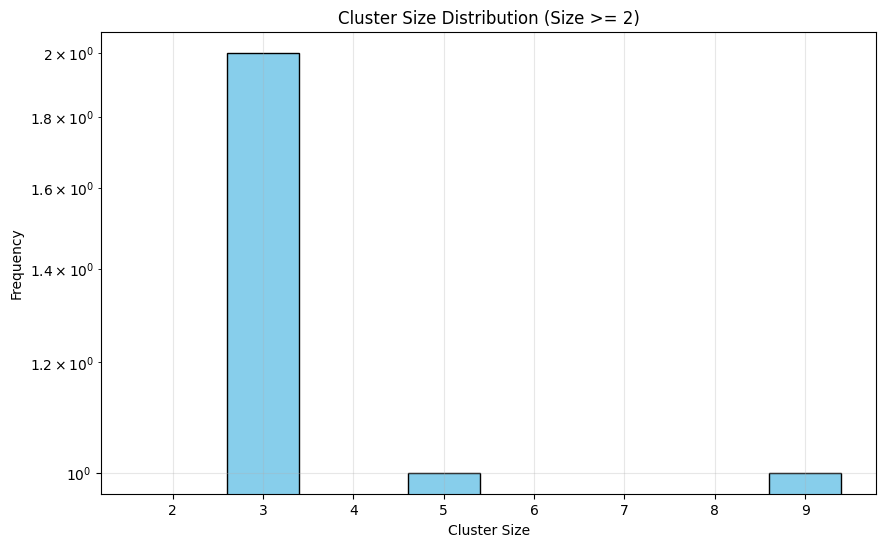

In [26]:

df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')

# Get labels, dropping any NaN
labels = df['Cluster_Label'].dropna().astype(int).tolist()  # Ensure integers

# Calculate cluster sizes (how many times each label appears)
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter for clusters with size >= 2
filtered_sizes = [size for size in cluster_sizes.values() if size >= 2]

# Check if there’s anything to plot
if not filtered_sizes:
    print("No clusters with size >= 2 found.")
else:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_sizes, bins=range(2, max(filtered_sizes) + 2), 
             align='left', rwidth=0.8, color='skyblue', edgecolor='black')
    plt.yscale('log')  # Log scale as requested earlier
    plt.xticks(range(2, max(filtered_sizes) + 1))  # Ensure integer x-axis
    plt.xlabel("Cluster Size")
    plt.ylabel("Frequency")
    plt.title("Cluster Size Distribution (Size >= 2)")
    plt.grid(True, alpha=0.3)
    plt.show()